#### 1) Importing Necessary Libraries:

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as Imbpipeline

import time

import warnings
warnings.filterwarnings('ignore')

In [2]:
import warnings
warnings.filterwarnings('ignore')

#### 2) Laoding Data:

In [3]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df.shape

(7032, 21)

In [8]:
df['Churn'].value_counts() / len(df) * 100

Churn
No     73.421502
Yes    26.578498
Name: count, dtype: float64

- We have a imbalanced Dataset here.
- We may need to use Over Sampling to get Model to learn more about Churned Customers.
- We have both Numeric and Categorical Data in Dataset.
- There are no missing values in dataset.

In [9]:
df['customerID'].nunique()

7032

- CustomerId is unique for each record, which won't help in Churn Prediction.

In [10]:
df.drop('customerID', axis= 1, inplace= True)

#### 3) Data Exploaration and Transformations:

In [11]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

##### 1) Checking Correlation of Features with Target Variable:

- As most of our features are of Object Datatype, we will have to convert those into numbers to calculate correlations.
- We will use LabelEncoder to convert all categorical features to numeric.

In [13]:
temp = df.copy() # Creating Copy of Dataframe to use LabelEncoder on

In [14]:
cat_cols = list(temp.select_dtypes(include= 'object').columns) # Storing names of Object type column in list.

le = LabelEncoder() #Label Encoder Instance

for col in cat_cols:
    temp[col] = le.fit_transform(df[col])

In [15]:
temp.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [16]:
# Correlation of Features with Target:

corr = temp.corr()

In [17]:
corr

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001819,-0.001379,0.010349,0.005285,-0.007515,-0.006908,-0.002236,-0.014899,-0.011920,0.001348,-0.006695,-0.005624,-0.008920,0.000095,-0.011902,0.016942,-0.013779,0.000048,-0.008545
SeniorCitizen,-0.001819,1.000000,0.016957,-0.210550,0.015683,0.008392,0.146287,-0.032160,-0.127937,-0.013355,-0.021124,-0.151007,0.031019,0.047088,-0.141820,0.156258,-0.038158,0.219874,0.102411,0.150541
Partner,-0.001379,0.016957,1.000000,0.452269,0.381912,0.018397,0.142717,0.000513,0.150610,0.153045,0.165614,0.126488,0.136679,0.129907,0.294094,-0.013957,-0.156232,0.097825,0.319072,-0.149982
Dependents,0.010349,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.024975,0.044030,0.151198,0.090231,0.079723,0.132530,0.046214,0.022088,0.240556,-0.110131,-0.041989,-0.112343,0.064653,-0.163128
tenure,0.005285,0.015683,0.381912,0.163386,1.000000,0.007877,0.343673,-0.029835,0.327283,0.372434,0.372669,0.324729,0.290572,0.296785,0.676734,0.004823,-0.370087,0.246862,0.825880,-0.354049
PhoneService,-0.007515,0.008392,0.018397,-0.001078,0.007877,1.000000,-0.020504,0.387266,-0.014163,0.024040,0.004718,-0.018136,0.056393,0.043025,0.003019,0.016696,-0.005499,0.248033,0.113008,0.011691
MultipleLines,-0.006908,0.146287,0.142717,-0.024975,0.343673,-0.020504,1.000000,-0.108849,0.007306,0.117276,0.122614,0.010941,0.175403,0.181705,0.111029,0.165306,-0.176598,0.433905,0.453202,0.038043
InternetService,-0.002236,-0.032160,0.000513,0.044030,-0.029835,0.387266,-0.108849,1.000000,-0.028003,0.036735,0.045558,-0.025626,0.108190,0.097967,0.099579,-0.138166,0.084504,-0.322173,-0.175691,-0.047097
OnlineSecurity,-0.014899,-0.127937,0.150610,0.151198,0.327283,-0.014163,0.007306,-0.028003,1.000000,0.184942,0.175789,0.284875,0.044399,0.056313,0.373980,-0.157723,-0.096593,-0.053576,0.254473,-0.289050
OnlineBackup,-0.011920,-0.013355,0.153045,0.090231,0.372434,0.024040,0.117276,0.036735,0.184942,1.000000,0.187646,0.195581,0.147085,0.137083,0.280617,-0.012697,-0.125534,0.119943,0.375556,-0.195290


In [18]:
corr['Churn']

gender             -0.008545
SeniorCitizen       0.150541
Partner            -0.149982
Dependents         -0.163128
tenure             -0.354049
PhoneService        0.011691
MultipleLines       0.038043
InternetService    -0.047097
OnlineSecurity     -0.289050
OnlineBackup       -0.195290
DeviceProtection   -0.177883
TechSupport        -0.282232
StreamingTV        -0.036303
StreamingMovies    -0.038802
Contract           -0.396150
PaperlessBilling    0.191454
PaymentMethod       0.107852
MonthlyCharges      0.192858
TotalCharges       -0.199484
Churn               1.000000
Name: Churn, dtype: float64

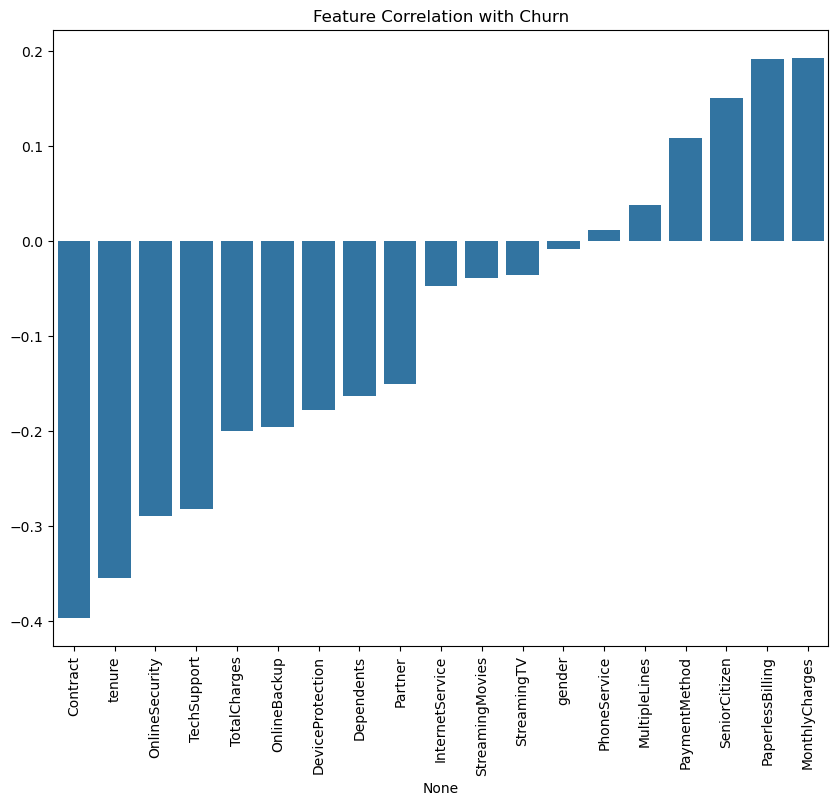

In [19]:
# Plotting Correlations of Features with Churn:

plt.figure(figsize= (10,8))
sns.barplot(x= corr['Churn'].sort_values().iloc[:-1].index, y= corr['Churn'].sort_values().iloc[:-1].values)
plt.title("Feature Correlation with Churn")
plt.xticks(rotation= 90)
plt.show()

##### 2) gender:

In [20]:
df['gender']

0       Female
1         Male
2         Male
3         Male
4       Female
         ...  
7027      Male
7028    Female
7029    Female
7030      Male
7031      Male
Name: gender, Length: 7032, dtype: object

In [21]:
df['gender'].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding.

In [22]:
gender_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 3) SeniorCitizen:

In [23]:
df['SeniorCitizen']

0       0
1       0
2       0
3       0
4       0
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: SeniorCitizen, Length: 7032, dtype: int64

In [24]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

- No Preprocessing needed.

##### 4) Partner:

In [25]:
df['Partner']

0       Yes
1        No
2        No
3        No
4        No
       ... 
7027    Yes
7028    Yes
7029    Yes
7030    Yes
7031     No
Name: Partner, Length: 7032, dtype: object

In [26]:
df['Partner'].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [27]:
partner_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 5) Dependents:

In [28]:
df['Dependents']

0        No
1        No
2        No
3        No
4        No
       ... 
7027    Yes
7028    Yes
7029    Yes
7030     No
7031     No
Name: Dependents, Length: 7032, dtype: object

In [29]:
df['Dependents'].value_counts()

Dependents
No     4933
Yes    2099
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding.

In [30]:
dependent_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 6) tenure:

In [31]:
df['tenure']

0        1
1       34
2        2
3       45
4        2
        ..
7027    24
7028    72
7029    11
7030     4
7031    66
Name: tenure, Length: 7032, dtype: int64

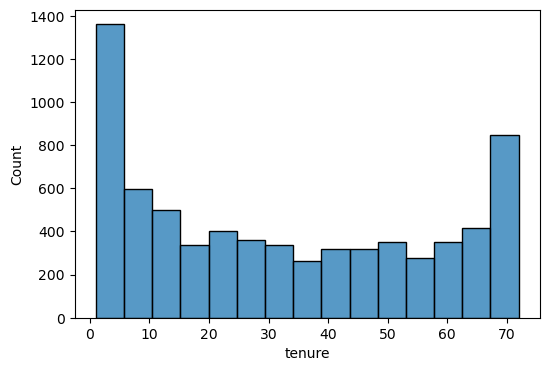

In [32]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'tenure')
plt.show()

- Preprocessing:
    - Scaling

In [33]:
tenure_pipe = Imbpipeline([
    ('sclare', StandardScaler())
])

##### 7) PhoneService:

In [34]:
df['PhoneService']

0        No
1       Yes
2       Yes
3        No
4       Yes
       ... 
7027    Yes
7028    Yes
7029     No
7030    Yes
7031    Yes
Name: PhoneService, Length: 7032, dtype: object

In [35]:
df['PhoneService'].value_counts()

PhoneService
Yes    6352
No      680
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [36]:
phservice_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 8) MultipleLines:

In [37]:
df['MultipleLines']

0       No phone service
1                     No
2                     No
3       No phone service
4                     No
              ...       
7027                 Yes
7028                 Yes
7029    No phone service
7030                 Yes
7031                  No
Name: MultipleLines, Length: 7032, dtype: object

In [38]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [39]:
multilines_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 9) InternetService:

In [40]:
df['InternetService']

0               DSL
1               DSL
2               DSL
3               DSL
4       Fiber optic
           ...     
7027            DSL
7028    Fiber optic
7029            DSL
7030    Fiber optic
7031    Fiber optic
Name: InternetService, Length: 7032, dtype: object

In [41]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [42]:
internetser_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 10) OnlineSecurity:

In [43]:
df['OnlineSecurity']

0        No
1       Yes
2       Yes
3       Yes
4        No
       ... 
7027    Yes
7028     No
7029    Yes
7030     No
7031    Yes
Name: OnlineSecurity, Length: 7032, dtype: object

In [44]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [45]:
onlinesec_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 11) OnlineBackup:

In [46]:
df['OnlineBackup']

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
7027     No
7028    Yes
7029     No
7030     No
7031     No
Name: OnlineBackup, Length: 7032, dtype: object

In [47]:
df['OnlineBackup'].value_counts()

OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [48]:
onlineback_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 12) DeviceProtection:

In [50]:
df['DeviceProtection']

0        No
1       Yes
2        No
3       Yes
4        No
       ... 
7027    Yes
7028    Yes
7029     No
7030     No
7031    Yes
Name: DeviceProtection, Length: 7032, dtype: object

In [51]:
df['DeviceProtection'].value_counts()

DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [52]:
devicepr_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 13) TechSupport:

In [54]:
df['TechSupport']

0        No
1        No
2        No
3       Yes
4        No
       ... 
7027    Yes
7028     No
7029     No
7030     No
7031    Yes
Name: TechSupport, Length: 7032, dtype: object

In [55]:
df['TechSupport'].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [56]:
techsup_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 14) StreamingTV:

In [58]:
df['StreamingTV']

0        No
1        No
2        No
3        No
4        No
       ... 
7027    Yes
7028    Yes
7029     No
7030     No
7031    Yes
Name: StreamingTV, Length: 7032, dtype: object

In [59]:
df['StreamingTV'].value_counts()

StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [64]:
streamtv_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 15) StreamingMovies:

In [62]:
df['StreamingMovies']

0        No
1        No
2        No
3        No
4        No
       ... 
7027    Yes
7028    Yes
7029     No
7030     No
7031    Yes
Name: StreamingMovies, Length: 7032, dtype: object

In [63]:
df['StreamingMovies'].value_counts()

StreamingMovies
No                     2781
Yes                    2731
No internet service    1520
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [65]:
streammv_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 16) Contract:

In [67]:
df['Contract']

0       Month-to-month
1             One year
2       Month-to-month
3             One year
4       Month-to-month
             ...      
7027          One year
7028          One year
7029    Month-to-month
7030    Month-to-month
7031          Two year
Name: Contract, Length: 7032, dtype: object

In [68]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [69]:
contract_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 17) PaperlessBilling:

In [72]:
df['PaperlessBilling']

0       Yes
1        No
2       Yes
3        No
4       Yes
       ... 
7027    Yes
7028    Yes
7029    Yes
7030    Yes
7031    Yes
Name: PaperlessBilling, Length: 7032, dtype: object

In [73]:
df['PaperlessBilling'].value_counts()

PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [74]:
paperlessbill_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 18) PaymentMethod:

In [76]:
df['PaymentMethod']

0                Electronic check
1                    Mailed check
2                    Mailed check
3       Bank transfer (automatic)
4                Electronic check
                  ...            
7027                 Mailed check
7028      Credit card (automatic)
7029             Electronic check
7030                 Mailed check
7031    Bank transfer (automatic)
Name: PaymentMethod, Length: 7032, dtype: object

In [77]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [78]:
paymentmthd_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 19) MonthlyCharges:

In [80]:
df['MonthlyCharges']

0        29.85
1        56.95
2        53.85
3        42.30
4        70.70
         ...  
7027     84.80
7028    103.20
7029     29.60
7030     74.40
7031    105.65
Name: MonthlyCharges, Length: 7032, dtype: float64

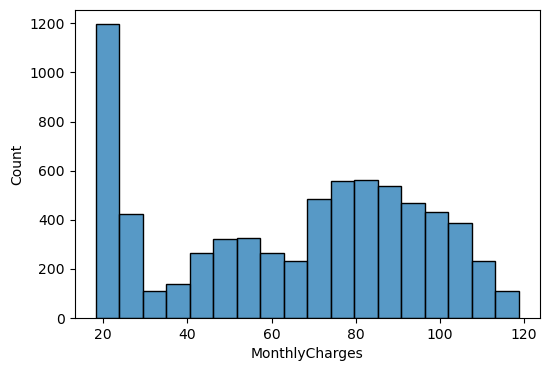

In [81]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'MonthlyCharges')
plt.show()

- Preprocessing:
    - Scaling

In [88]:
monthlychrgs_pipe = Imbpipeline([
    ('scaler', StandardScaler())
])

##### 20) TotalCharges:

In [90]:
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7027    1990.50
7028    7362.90
7029     346.45
7030     306.60
7031    6844.50
Name: TotalCharges, Length: 7032, dtype: float64

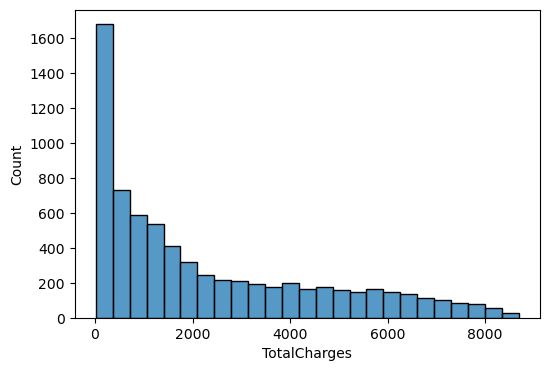

In [91]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'TotalCharges')
plt.show()

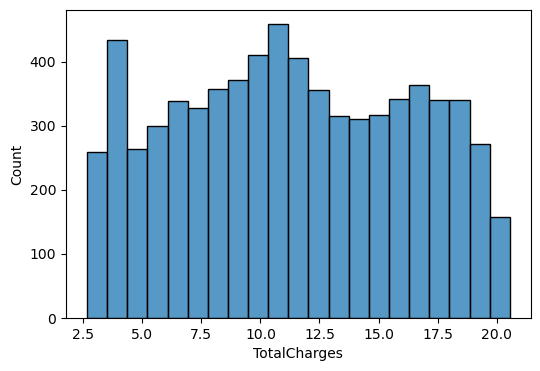

In [97]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['TotalCharges'].apply(np.cbrt))
plt.show()

- Preprocessing:
    - Cube Root Transformation,
    - Scaling

In [98]:
totalchrgs_pipe = Imbpipeline([
    ('transformation', FunctionTransformer(np.cbrt)),
    ('scaler', StandardScaler())
])

#### 4) Final Column Transformer:

In [99]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [100]:
preprocessor = ColumnTransformer([
    ('gender', gender_pipe, ['gender']),
    ('Partner', partner_pipe, ['Partner']),
    ('Dependents', dependent_pipe, ['Dependents']),
    ('tenure', tenure_pipe, ['tenure']),
    ('PhoneService', phservice_pipe, ['PhoneService']),
    ('MultipleLines', multilines_pipe, ['MultipleLines']),
    ('InternetService', internetser_pipe, ['InternetService']),
    ('OnlineSecurity', onlinesec_pipe, ['OnlineSecurity']),
    ('OnlineBackup', onlineback_pipe, ['OnlineBackup']),
    ('DeviceProtection', devicepr_pipe, ['DeviceProtection']),
    ('TechSupport', techsup_pipe, ['TechSupport']),
    ('StreamingTV', streamtv_pipe, ['StreamingTV']),
    ('StreamingMovies', streammv_pipe, ['StreamingMovies']),
    ('Contract', contract_pipe, ['Contract']),
    ('PaperlessBilling', paperlessbill_pipe, ['PaperlessBilling']),
    ('PaymentMethod', paymentmthd_pipe, ['PaymentMethod']),
    ('MonthlyCharges', monthlychrgs_pipe, ['MonthlyCharges']),
    ('TotalCharges', totalchrgs_pipe, ['TotalCharges'])
], remainder= 'passthrough')

#### 5) Train Test Split:

In [126]:
X = df.drop('Churn', axis= 1) #Features
y = df['Churn'] #Target

In [127]:
y.value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [128]:
# Mapping No: 0, Yes: 1 (XGBoost needs target to be Numeric)

y = y.map({'No': 0, 'Yes': 1})

In [129]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [131]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 19)
(1407, 19)
(5625,)
(1407,)


#### 6) Model Building and Evaluation:

- We will use Grid Search on all models.
- We will build all the models twice, one without Over Sampling and one with, to compare improvement in Churn detection, if any.

In [158]:
# Defining a Dictionary of Models and Their Parameters to Loop through:

"""
Dictionary Format:
dict = {
'Model_Name': (Model_Instance,
               {clf__param1: value,
               clf__param2: value}
               )
}
"""

model_config = {
    'Logistic_Regression': (
        LogisticRegression(),
        {'clf__C': np.logspace(-3, 3, 7),
        'clf__penalty': ['l1', 'l2'],
        'clf__solver': ['liblinear', 'saga']}
    ),

    'Logistic_Regression_with_OverSampling': (
        LogisticRegression(),
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__C': np.logspace(-3, 3, 7),
        'clf__penalty': ['l1', 'l2'],
        'clf__solver': ['liblinear', 'saga']}
    ),

    'SVC': (
        SVC(probability= True), # For model to return probabilites for each class too
        {'clf__kernel': ['poly', 'linear', 'rbf', 'sigmoid'],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__degree': [2,3],
        'clf__gamma': ['scale', 'auto']
        }
    ),

    'SVC_with_OverSampling': (
        SVC(probability= True), # For model to return probabilites for each class too
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__kernel': ['poly', 'linear', 'rbf', 'sigmoid'],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__degree': [2,3],
        'clf__gamma': ['scale', 'auto']
        }
    ),

    'Naive_Bayes': (
        GaussianNB(),
        {'clf__var_smoothing': np.logspace(0, -9, num=100)}
    ),

    'Naive_Bayes_with_OverSampling': (
        GaussianNB(),
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__var_smoothing': np.logspace(0, -9, num=100)
        }
    ),

    'KNN': (
        KNeighborsClassifier(),
        {'clf__n_neighbors': list(range(1,25)),
        'clf__metric': ['euclidean', 'manhattan', 'cosine', 'minkowski']
        }
    ),

    'KNN_with_OverSampling': (
        KNeighborsClassifier(),
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__n_neighbors': list(range(1,25)),
        'clf__metric': ['euclidean', 'manhattan', 'cosine', 'minkowski']
        }
    ),

    'Decision_Tree': (
        DecisionTreeClassifier(),
        {'clf__criterion': ['gini', 'entropy'],
        'clf__max_depth': [2, 5, 10, None],
        'clf__min_samples_split': [2, 5, 10, 20],
        'clf__min_samples_leaf': [1, 2, 4]
        }
    ),

    'Decision_Tree_with_OverSampling': (
        DecisionTreeClassifier(),
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__criterion': ['gini', 'entropy'],
        'clf__max_depth': [2, 5, 10, None],
        'clf__min_samples_split': [2, 5, 10, 20],
        'clf__min_samples_leaf': [1, 2, 4]
        }
    ),

    'Random_Forest': (
        RandomForestClassifier(random_state= 42, oob_score= True, n_jobs= -1),
        {'clf__n_estimators': [50, 100, 500],
        'clf__max_depth': [5, 10],
        'clf__criterion': ['gini', 'entropy']}
    ),

    'Random_Forest_with_OverSampling': (
        RandomForestClassifier(random_state= 42, oob_score= True, n_jobs= -1),
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__n_estimators': [50, 100, 500],
        'clf__max_depth': [5, 10],
        'clf__criterion': ['gini', 'entropy']}
    ),

    'Bagging': (
        BaggingClassifier(random_state= 42),
        {'clf__n_estimators': [50, 100, 500],
        'clf__max_samples': [0.5, 1.0]}
    ),

    'Bagging_with_OverSampling': (
        BaggingClassifier(random_state= 42),
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__n_estimators': [50, 100, 500],
        'clf__max_samples': [0.5, 1.0]}
    ),

    'Extra_Trees': (
        ExtraTreesClassifier(random_state= 42),
        {'clf__n_estimators': [50, 100, 500],
        'clf__criterion': ['gini', 'entropy']}
    ),

    'Extra_Trees_with_OverSampling': (
        ExtraTreesClassifier(random_state= 42),
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__n_estimators': [50, 100, 500],
        'clf__criterion': ['gini', 'entropy']}
    ),

    'AdaBoost': (
        AdaBoostClassifier(random_state= 42),
        {'clf__n_estimators': [50, 100, 500],
        'clf__learning_rate': [0.01, 0.1, 0.2, 0.3, 0.5]}
    ),

    'AdaBoost_with_OverSampling': (
        AdaBoostClassifier(random_state= 42),
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__n_estimators': [50, 100, 500],
        'clf__learning_rate': [0.01, 0.1, 0.2, 0.3, 0.5]}
    ),

    'GradientBoost': (
        GradientBoostingClassifier(random_state= 42),
        {'clf__n_estimators': [50, 100, 500],
        'clf__learning_rate': [0.01, 0.1, 0.2, 0.3, 0.5],
        'clf__max_depth': [3, 5]}
    ),

    'GradientBoost_with_OverSampling': (
        GradientBoostingClassifier(random_state= 42),
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__n_estimators': [50, 100, 500],
        'clf__learning_rate': [0.01, 0.1, 0.2, 0.3, 0.5],
        'clf__max_depth': [3, 5]}
    ),

    'XGBoost': (
        XGBClassifier(random_state=42, eval_metric='logloss'),
        {'clf__n_estimators': [50, 100, 500], 
         'clf__learning_rate': [0.01, 0.1, 0.2, 0.3, 0.5], 
         'clf__max_depth': [3, 5]}
    ),

    'XGBoost_with_OverSampling': (
        XGBClassifier(random_state=42, eval_metric='logloss'),
        {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
        'clf__n_estimators': [50, 100, 500], 
        'clf__learning_rate': [0.01, 0.1, 0.2, 0.3, 0.5], 
        'clf__max_depth': [3, 5]}
    ),
}

In [133]:
# Grid Search on all Above Defined Models:

result_list = [] 
best_models = {}

print(f"{'Model':<100} | {'Status':<10} | {'Time'}")
print("-" * 120)

for name, (model, params) in model_config.items():
    start_time = time.time()

    try:
        # Checking if Model is with or without OverSampling:
        if 'OverSampling' in name:
            # Creating Pipeline with Preprocessing, SMOTE (Over Sampling) and Model:
            model_pipe = Imbpipeline([
                ('Preprocessing', preprocessor),
                ('Over_Sampling', SMOTE(random_state= 42)),
                ('clf', model)
            ])
        else:
            # Creating Pipeline with Preprocessing and Model:
            model_pipe = Imbpipeline([
                ('Preprocessing', preprocessor),
                ('clf', model)
            ])

        #Creting Grid Search:
        grid = GridSearchCV(estimator= model_pipe,
                           param_grid= params,
                           cv= 5,
                           scoring= 'f1', # Because we have Data with Imbalanced Classes
                           n_jobs= -1)

        #Fitting the Grid:
        grid.fit(X_train, y_train)

        #Storing best estimator from the Grid Search:
        best_models[name] = grid.best_estimator_

        #Duration of Grid Search:
        duration = time.time() - start_time

        #Storing Results
        result_list.append({
            'Model': name,
            'Best CV Score': grid.best_score_,
            'Best Params': grid.best_params_,
            'Duration (s)': round(duration, 2)
        })

        print(f"{name:<100} | {'Success':<10} | {duration:.2f}s")

    except Exception as e:
        print(f"{name:<100} | {'FAILED':<10} | Error: {str(e)}")

Model                                                                                                | Status     | Time
------------------------------------------------------------------------------------------------------------------------
Logistic_Regression                                                                                  | Success    | 2.97s
Logistic_Regression_with_OverSampling                                                                | Success    | 10.21s
SVC                                                                                                  | Success    | 48.26s
SVC_with_OverSampling                                                                                | Success    | 339.60s
Naive_Bayes                                                                                          | Success    | 3.82s
Naive_Bayes_with_OverSampling                                                                        | Success    | 13.75s
KNN                  

In [134]:
# Results:

result_df = pd.DataFrame(data= result_list).sort_values(by= 'Best CV Score', ascending= False)
result_df

,Model,Best CV Score,Best Params,Duration (s)
21,XGBoost_with_OverSampling,0.647102,{'Over_Sampling__sampling_strategy': 'minority...,18.33
19,GradientBoost_with_OverSampling,0.645986,{'Over_Sampling__sampling_strategy': 'minority...,166.06
1,Logistic_Regression_with_OverSampling,0.643429,"{'Over_Sampling__sampling_strategy': 0.75, 'cl...",10.21
17,AdaBoost_with_OverSampling,0.642921,"{'Over_Sampling__sampling_strategy': 0.75, 'cl...",39.15
3,SVC_with_OverSampling,0.640514,"{'Over_Sampling__sampling_strategy': 0.75, 'cl...",339.60
11,Random_Forest_with_OverSampling,0.634742,"{'Over_Sampling__sampling_strategy': 0.75, 'cl...",22.97
7,KNN_with_OverSampling,0.623425,"{'Over_Sampling__sampling_strategy': 0.5, 'clf...",27.50
8,Decision_Tree,0.620966,"{'clf__criterion': 'entropy', 'clf__max_depth'...",4.62
4,Naive_Bayes,0.618880,{'clf__var_smoothing': 1.0},3.82
9,Decision_Tree_with_OverSampling,0.616360,"{'Over_Sampling__sampling_strategy': 0.75, 'cl...",15.60


#### 7) Predictions on Test Data Using Best Estimator fro Grid Search:

In [139]:
name = result_df.iloc[0]['Model']
best_model = best_models[name]

In [140]:
best_model

,steps,"[('Preprocessing', ...), ('Over_Sampling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('gender', ...), ('Partner', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [141]:
print(best_model)

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender']),
                                                 ('Partner',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Partner']),
                                                 ('Dependents',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore...
                               fe

In [142]:
# Predictions on Test Data:

y_pred = best_model.predict(X_test)

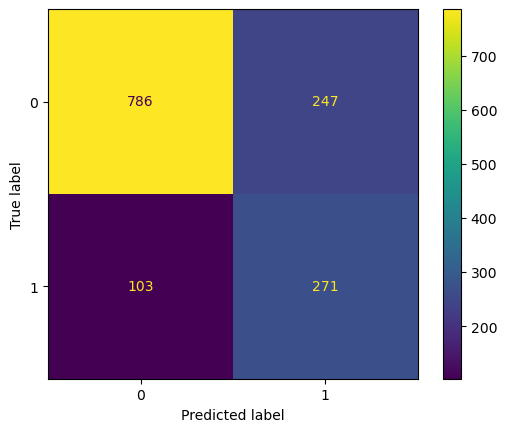

In [143]:
# Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= best_model.classes_)
disp.plot()
plt.show()

In [144]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1033
           1       0.52      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



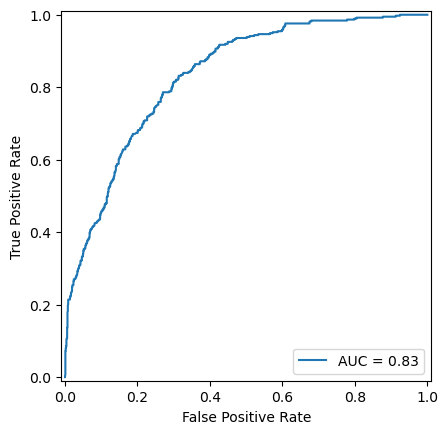

In [157]:
# ROC-AUC Curve:

y_scores = best_model.predict_proba(X_test)[:,1] # Selecting only the probabilites for class 1.
fpr, tpr, thresholds = roc_curve(y_test,y_scores)
roc_auc = auc(fpr, tpr)
disp = RocCurveDisplay(fpr= fpr, tpr= tpr, roc_auc= roc_auc)
disp.plot()
plt.show()